In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams.update({'font.size': 10})
colors = plt.colormaps['tab20']

In [3]:
bound = lambda k, mu, s0: upper(k,mu, s0) - lower(k,mu,s0)

def upper(k,mu, s0, m=None, tol=1e-20, maxfloat=1e6):
    c = k*(1+mu)
    assert np.array(c).squeeze().ndim == 0 or np.array(s0).squeeze().ndim == 0
    if np.array(c).squeeze().ndim > 0:
        assert c.ndim == 1
        return np.array([upper(a, s0, m, tol) for a in c])
    if np.array(s0).squeeze().ndim > 0:
        assert s0.ndim == 1
        return np.array([upper(c, a, m, tol) for a in s0])
    if s0 < 0:
        return np.nan
    r = 0
    t = 1
    i = -1
    overflowcount = 0
    while True:
        i += 1
        if i > 0:
            t *= s0/i
        a = t * (c + s0)/(c + i)
        if i > 0 and np.abs(a/r) < tol:
            break
        r += a
        if m is not None and i >= m:
            break
        if r > maxfloat:
            r /= maxfloat
            t /= maxfloat
            overflowcount += 1
    r = np.exp(np.log(r) + overflowcount*np.log(maxfloat) - s0)
    return r

def lower(k,mu, s0):
    return (k*(1+mu) + s0)/(k+1+(k-1)*mu + s0)

In [4]:
def calc_k_mu_s0(p,y_hat):
    if np.sum(y_hat) == 0:
        print("Null Output")
        return None, None, None
    k = np.sum(y_hat)
    mu = np.sum(y_hat*p)/k
    s0 = np.sum((1-y_hat)*p)
    return k, mu, s0

In [5]:
from collections import defaultdict
dict_lower_bounds = defaultdict(list)
dict_upper_bounds = defaultdict(list)
dict_bounds = defaultdict(list)
dict_delta_bounds = defaultdict(list)
dict_epsilon_bounds = defaultdict(list)

In [6]:
import os
### BRATS
tresh = 0.5
folder_path = '../../data/BraTS_preds/BraTS_preds_clean_binary_3D/'

y = np.load(os.path.join(folder_path,'y_tracked.npy'))

p_hat = np.load(os.path.join(folder_path,'y_hat_tracked.npy'))

print(y.shape, p_hat.shape)

for p_hat_i in p_hat:
    y_hat_i = p_hat_i>tresh
    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)
    if (k != None) and (mu!= None) and (s0!= None):
        dict_lower_bounds['BraTS'].append(lower(k,mu, s0))
        dict_upper_bounds['BraTS'].append(upper(k,mu, s0))
        dict_delta_bounds['BraTS'].append(upper(k,mu, s0)-lower(k,mu, s0))
        dict_bounds['BraTS'].append(lower(k,mu, s0))
        dict_bounds['BraTS'].append(upper(k,mu, s0))
        dict_epsilon_bounds['BraTS'].append(max((1/lower(k,mu, s0)-1),(1-1/upper(k,mu, s0))))

(74, 1, 155, 240, 240) (74, 1, 155, 240, 240)


In [7]:
#### BUSI
tresh = 0.5
data = np.load('../../data/busi_wo_null_unext_model/test/busi_unext_test.npz')

y = data['y']
p_hat = data['y_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

print(y.shape, p_hat.shape)

for p_hat_i in p_hat:
    y_hat_i = p_hat_i>tresh
    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)
    if (k != None) and (mu!= None) and (s0!= None):
        dict_lower_bounds['BUSI'].append(lower(k,mu, s0))
        dict_upper_bounds['BUSI'].append(upper(k,mu, s0))
        dict_delta_bounds['BUSI'].append(upper(k,mu, s0)-lower(k,mu, s0))
        dict_bounds['BUSI'].append(lower(k,mu, s0))
        dict_bounds['BUSI'].append(upper(k,mu, s0))
        dict_epsilon_bounds['BUSI'].append(max((1/lower(k,mu, s0)-1),(1-1/upper(k,mu, s0))))

(98, 1, 256, 256) (98, 1, 256, 256)
Null Output
Null Output
Null Output
Null Output


In [8]:
### ISIC ID
tresh = 0.5
data = np.load('./repo_unext_isic/outputs/isic_unext_model_unified/test/isic_unext_model_unified.npz')

y = data['y']
p_hat = data['y_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

print(y.shape, p_hat.shape)

for p_hat_i in p_hat:
    y_hat_i = p_hat_i>tresh
    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)
    if (k != None) and (mu!= None) and (s0!= None):
#        dict_lower_bounds['isic-ID'].append(lower(k,mu, s0))
#        dict_upper_bounds['isic-ID'].append(upper(k,mu, s0))
        dict_lower_bounds['ISIC'].append(lower(k,mu, s0))
        dict_upper_bounds['ISIC'].append(upper(k,mu, s0))
        dict_delta_bounds['ISIC'].append(upper(k,mu, s0)-lower(k,mu, s0))
        dict_bounds['ISIC'].append(lower(k,mu, s0))
        dict_bounds['ISIC'].append(upper(k,mu, s0))
        dict_epsilon_bounds['ISIC'].append(max((1/lower(k,mu, s0)-1),(1-1/upper(k,mu, s0))))

(1000, 1, 512, 512) (1000, 1, 512, 512)


In [8]:
### ISIC OOD
'''tresh = 0.5
data = np.load('./repo_unext_isic/outputs/isic_unext_model_2/test/isic_unext_model_2.npz')

y = data['y']
p_hat = data['y_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

print(y.shape, p_hat.shape)

for p_hat_i in p_hat:
    y_hat_i = p_hat_i>tresh
    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)
    if (k != None) and (mu!= None) and (s0!= None):
        dict_lower_bounds['isic-OOD'].append(lower(k,mu, s0))
        dict_upper_bounds['isic-OOD'].append(upper(k,mu, s0))'''

"tresh = 0.5\ndata = np.load('./repo_unext_isic/outputs/isic_unext_model_2/test/isic_unext_model_2.npz')\n\ny = data['y']\np_hat = data['y_hat']\n\nzero_preds = np.all(y == 0, axis=(-2,-1)).flatten()\np_hat= p_hat[~zero_preds]\ny = y[~zero_preds]\n\nprint(y.shape, p_hat.shape)\n\nfor p_hat_i in p_hat:\n    y_hat_i = p_hat_i>tresh\n    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)\n    if (k != None) and (mu!= None) and (s0!= None):\n        dict_lower_bounds['isic-OOD'].append(lower(k,mu, s0))\n        dict_upper_bounds['isic-OOD'].append(upper(k,mu, s0))"

In [9]:
import pickle
### MSWML
tresh = 0.35
with open('./mswml/eval_in_predictions.pkl', 'rb') as file:
    # Save the list to the file
    p_hat =  pickle.load(file)

with open('./mswml/eval_in_gt.pkl', 'rb') as file:
    # Save the list to the file
    y =  pickle.load(file)
    
print(len(y), len(p_hat))

for p_hat_i in p_hat:
    p_hat_i = np.array(p_hat_i)
    y_hat_i = p_hat_i>tresh
    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)
    if (k != None) and (mu!= None) and (s0!= None):
        dict_lower_bounds['MSWML'].append(lower(k,mu, s0))
        dict_upper_bounds['MSWML'].append(upper(k,mu, s0))
        dict_delta_bounds['MSWML'].append(upper(k,mu, s0)-lower(k,mu, s0))
        dict_bounds['MSWML'].append(lower(k,mu, s0))
        dict_bounds['MSWML'].append(upper(k,mu, s0))
        dict_epsilon_bounds['MSWML'].append(max((1/lower(k,mu, s0)-1),(1-1/upper(k,mu, s0))))

33 33


In [10]:
import cv2
import os
import numpy as np
def read_images_in_directory_in(directory_path_GT):
    image_data_GT = []
    image_data_PolypPVT = []
    image_data_UNET = []
    for root, dirs, files in os.walk(directory_path_GT):
        for file in files:
            if file.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')) and ((('Kvasir' in root) or ('CVC-ClinicDB' in root)) and('.ipynb_checkpoints' not in root)):
                image_path_GT = os.path.join(root, file)
                image_path_PolypPVT = os.path.join(root.replace('GT','PolypPVT'), file)
                image_path_UNET= os.path.join(root.replace('GT','UNET'), file)
                # Read the image in grayscale
                image_data_GT.append(cv2.resize(cv2.imread(image_path_GT, cv2.IMREAD_GRAYSCALE), (352, 352), interpolation = cv2.INTER_NEAREST)/255>0.5)
                image_data_PolypPVT.append(cv2.resize(cv2.imread(image_path_PolypPVT, cv2.IMREAD_GRAYSCALE), (352, 352), interpolation = cv2.INTER_NEAREST)/255)
                image_data_UNET.append(cv2.resize(cv2.imread(image_path_UNET, cv2.IMREAD_GRAYSCALE), (352, 352), interpolation = cv2.INTER_NEAREST)/255)
    
    return np.array(image_data_GT), np.array(image_data_PolypPVT), np.array(image_data_UNET)


# Specify the directory path where your images are located
directory_path_GT = './polyp/GT/Test/'
all_sm_preds = dict()
# Read the images and store them in a NumPy array and convert the list of images into a NumPy array
y, all_sm_preds['PVT'], all_sm_preds['UNET'] =read_images_in_directory_in(directory_path_GT)



In [11]:
### POLYP PVT
tresh = 0.5
y = np.expand_dims(y, axis=1)
p_hat = np.expand_dims(all_sm_preds['PVT'], axis=1)

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

#binary_y_hat =  y_hat>0.5
#zero_preds = np.all(binary_y_hat == 0, axis=(-2,-1)).flatten()
#y_hat= y_hat[~zero_preds]
#y = y[~zero_preds]


print(len(y), len(p_hat))

for p_hat_i in p_hat:
    y_hat_i = p_hat_i>tresh
    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)
    if (k != None) and (mu!= None) and (s0!= None):
        dict_lower_bounds['Polyp'].append(lower(k,mu, s0))
        dict_upper_bounds['Polyp'].append(upper(k,mu, s0))
        dict_delta_bounds['Polyp'].append(upper(k,mu, s0)-lower(k,mu, s0))
        dict_bounds['Polyp'].append(lower(k,mu, s0))
        dict_bounds['Polyp'].append(upper(k,mu, s0))
        dict_epsilon_bounds['Polyp'].append(max((1/lower(k,mu, s0)-1),(1-1/upper(k,mu, s0))))

162 162


In [12]:
### POLYP UNET
'''tresh = 0.5
y = np.expand_dims(y, axis=1)
p_hat = np.expand_dims(all_sm_preds['UNET'], axis=1)

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

#binary_y_hat =  y_hat>0.5
#zero_preds = np.all(binary_y_hat == 0, axis=(-2,-1)).flatten()
#y_hat= y_hat[~zero_preds]
#y = y[~zero_preds]


print(len(y), len(p_hat))

for p_hat_i in p_hat:
    y_hat_i = p_hat_i>tresh
    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)
    if (k != None) and (mu!= None) and (s0!= None):
        dict_lower_bounds['polyp-unet'].append(lower(k,mu, s0))
        dict_upper_bounds['polyp-unet'].append(upper(k,mu, s0))'''

"tresh = 0.5\ny = np.expand_dims(y, axis=1)\np_hat = np.expand_dims(all_sm_preds['UNET'], axis=1)\n\nzero_preds = np.all(y == 0, axis=(-2,-1)).flatten()\np_hat= p_hat[~zero_preds]\ny = y[~zero_preds]\n\n#binary_y_hat =  y_hat>0.5\n#zero_preds = np.all(binary_y_hat == 0, axis=(-2,-1)).flatten()\n#y_hat= y_hat[~zero_preds]\n#y = y[~zero_preds]\n\n\nprint(len(y), len(p_hat))\n\nfor p_hat_i in p_hat:\n    y_hat_i = p_hat_i>tresh\n    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)\n    if (k != None) and (mu!= None) and (s0!= None):\n        dict_lower_bounds['polyp-unet'].append(lower(k,mu, s0))\n        dict_upper_bounds['polyp-unet'].append(upper(k,mu, s0))"

In [12]:
### REFUGE
tresh = 0.5
task = 'cup'
data = np.load('../../../data/refuge/test/%s_reshape.npz'%task)

y = data['y']
p_hat = data['y_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]


#binary_y_hat =  y_hat>0.5
#zero_preds = np.all(binary_y_hat == 0, axis=(-2,-1)).flatten()
#y_hat= y_hat[~zero_preds]
#y = y[~zero_preds]


print(len(y), len(p_hat))

for p_hat_i in p_hat:
    y_hat_i = p_hat_i>tresh
    k, mu, s0 = calc_k_mu_s0(p_hat_i,y_hat_i)
    if (k != None) and (mu!= None) and (s0!= None):
        dict_lower_bounds['REFUGE'].append(lower(k,mu, s0))
        dict_upper_bounds['REFUGE'].append(upper(k,mu, s0))
        dict_delta_bounds['REFUGE'].append(upper(k,mu, s0)-lower(k,mu, s0))
        dict_bounds['REFUGE'].append(lower(k,mu, s0))
        dict_bounds['REFUGE'].append(upper(k,mu, s0))
        dict_epsilon_bounds['REFUGE'].append(max((1/lower(k,mu, s0)-1),(1-1/upper(k,mu, s0))))

240 240


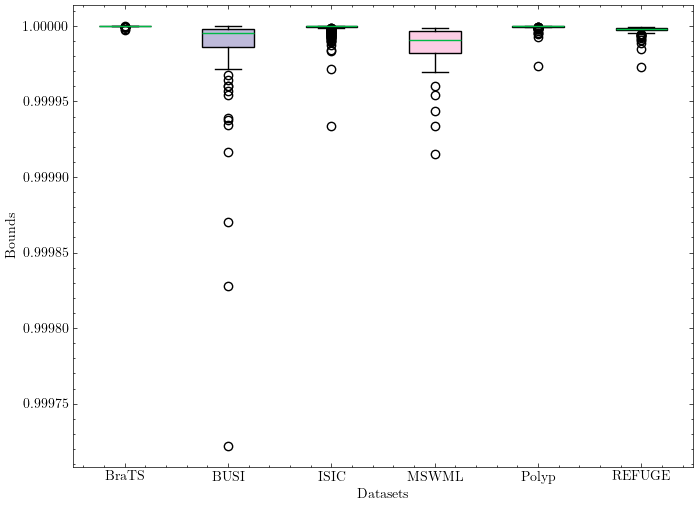

In [13]:
# Generate distinct colors based on the number of categories
num_categories = len(dict_lower_bounds)
cmap = plt.get_cmap('Set3')  # Choosing a color map
colors = cmap(np.linspace(0, 1, num_categories))  # Generate colors

# Create a box plot
plt.figure(figsize=(8, 6))
box = plt.boxplot(dict_lower_bounds.values(), labels=dict_lower_bounds.keys(), patch_artist=True)

# Assign different colors to each box dynamically
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

#plt.title('Box Plot for Lower Bounds')
plt.xlabel('Datasets')
plt.ylabel('Bounds')
plt.savefig("./Journal_Graphs/Lower_Bounds.pdf", format="pdf")
# Show the plot
plt.show()

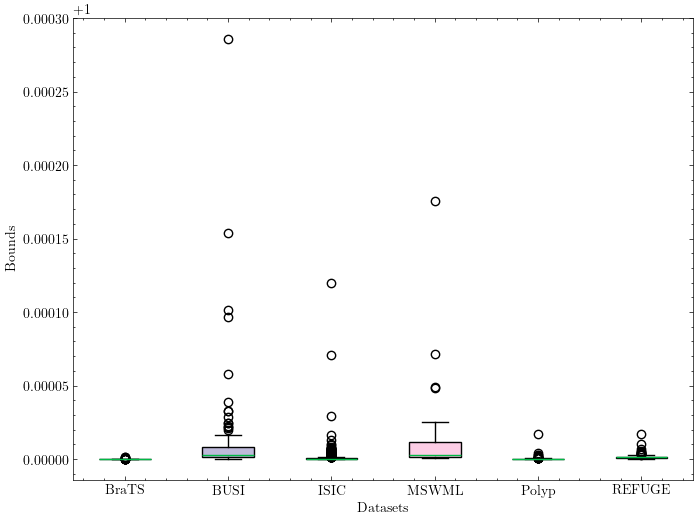

In [14]:
# Generate distinct colors based on the number of categories
num_categories = len(dict_upper_bounds)
cmap = plt.get_cmap('Set3')  # Choosing a color map
colors = cmap(np.linspace(0, 1, num_categories))  # Generate colors

# Create a box plot
plt.figure(figsize=(8, 6))
box = plt.boxplot(dict_upper_bounds.values(), labels=dict_upper_bounds.keys(), patch_artist=True)

# Assign different colors to each box dynamically
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

#plt.title('Box Plot for Upper Bounds')
plt.xlabel('Datasets')
plt.ylabel('Bounds')
plt.savefig("./Journal_Graphs/Upper_Bounds.pdf", format="pdf")
# Show the plot
plt.show()

In [17]:
import pandas as pd

def generate_latex_table(data):
    # Convert dictionary to DataFrame, handling unequal lengths by filling with NaN
    max_length = max(len(v) for v in data.values())
    padded_data = {key: values + [np.nan] * (max_length - len(values)) for key, values in data.items()}
    df = pd.DataFrame(padded_data)
    
    summary_stats = df.agg(['min', 'max', 'median']).transpose()
    
    # Format the values to 5 decimal places
    summary_stats = summary_stats.round(5)
    
    # Generate the LaTeX table
    latex_table = "\\begin{table}[h!]\n\\centering\n\\begin{tabular}{|l|r|r|r|}\n\\hline\n"
    latex_table += "Dataset & Min & Max & Median \\\\\n\\hline\n"
    for col in summary_stats.index:
        min_val = f"{summary_stats.loc[col, 'min']:.5f}"
        max_val = f"{summary_stats.loc[col, 'max']:.5f}"
        median_val = f"{summary_stats.loc[col, 'median']:.5f}"
        latex_table += f"{col} & {min_val} & {max_val} & {median_val} \\\\\n"
    latex_table += "\\hline\n\\end{tabular}\n\\caption{Summary Statistics Table}\n\\label{tab:summary_stats}\n\\end{table}"
    
    return latex_table

In [35]:
import numpy as np
import pandas as pd

def scientific_notation_around_one(value):
    """Format a number close to 1 in scientific notation as 1 +/- small deviation."""
    if pd.isna(value):
        return "NaN"
    deviation = value - 1
    if np.isclose(deviation, 0, atol=1e-50):
        return "$1.0$	"
    elif deviation > 0:
        base, exponent = f"{deviation:.1e}".split("e")
        return f"$1.0 + {float(base):.1f} \\times 10^{{{int(exponent)}}}$"
    else:
        base, exponent = f"{abs(deviation):.1e}".split("e")
        return f"$1.0 - {float(base):.1f} \\times 10^{{{int(exponent)}}}$"

def scientific_notation_around_zero(value):
    """Format a number close to 0 in scientific notation"""
    if pd.isna(value):
        return "NaN"
    if np.isclose(value, 0, atol=1e-50):
        return "$0.0$	"
    else:
        base, exponent = f"{value:.1e}".split("e")
        return f"${float(base):.1f} \\times 10^{{{int(exponent)}}}$"

def generate_latex_table(data, data_delta):
    # Convert dictionary to DataFrame, handling unequal lengths by filling with NaN
    max_length = max(len(v) for v in data.values())
    padded_data = {key: values + [np.nan] * (max_length - len(values)) for key, values in data.items()}
    df = pd.DataFrame(padded_data)

    max_length_delta = max(len(v) for v in data_delta.values())
    padded_data_delta = {key: values + [np.nan] * (max_length_delta - len(values)) for key, values in data_delta.items()}
    df_delta = pd.DataFrame(padded_data_delta)
    
    summary_stats = df.agg(['min', 'max', 'median']).transpose()
    summary_stats_delta= df_delta.agg(['max', 'mean']).transpose()
    
    # Generate the LaTeX table
    latex_table = "\\begin{table}[h!]\n\\centering\n\\begin{tabular}{|l|c|c|c|c|}\n\\hline\n"
    latex_table += "\\textbf{Dataset} & \textbf{Min($b_L$)} & \textbf{Max($b_U$)} & \textbf{Max($b_U - b_L$)} & \textbf{Mean($b_U - b_L$)} \\\\ \n\\hline\n"
    for col in summary_stats.index:
        min_val = scientific_notation_around_one(summary_stats.loc[col, 'min'])
        max_val = scientific_notation_around_one(summary_stats.loc[col, 'max'])
        max_val_delta = scientific_notation_around_zero(summary_stats_delta.loc[col, 'max'])
        mean_val_delta = scientific_notation_around_zero(summary_stats_delta.loc[col, 'mean'])
        latex_table += f"\\texttt{{{col}}} & {min_val} & {max_val} & {max_val_delta} & {mean_val_delta} \\\\ \n"
    latex_table += "\\hline\n\\end{tabular}\n\\caption{Summary Statistics for Each Dataset}\n\\label{tab:summary_stats}\n\\end{table}"

    return latex_table



In [36]:
print(generate_latex_table(dict_bounds,dict_delta_bounds))

\begin{table}[h!]
\centering
\begin{tabular}{|l|c|c|c|c|}
\hline
\textbf{Dataset} & 	extbf{Min($b_L$)} & 	extbf{Max($b_U$)} & 	extbf{Max($b_U - b_L$)} & 	extbf{Mean($b_U - b_L$)} \\ 
\hline
\texttt{BraTS} & $1.0 - 2.4 \times 10^{-6}$ & $1.0 + 1.3 \times 10^{-6}$ & $3.7 \times 10^{-6}$ & $3.4 \times 10^{-7}$ \\ 
\texttt{BUSI} & $1.0 - 2.8 \times 10^{-4}$ & $1.0 + 2.9 \times 10^{-4}$ & $5.6 \times 10^{-4}$ & $3.0 \times 10^{-5}$ \\ 
\texttt{ISIC} & $1.0 - 6.6 \times 10^{-5}$ & $1.0 + 1.2 \times 10^{-4}$ & $1.9 \times 10^{-4}$ & $1.7 \times 10^{-6}$ \\ 
\texttt{MSWML} & $1.0 - 8.5 \times 10^{-5}$ & $1.0 + 1.8 \times 10^{-4}$ & $2.6 \times 10^{-4}$ & $3.2 \times 10^{-5}$ \\ 
\texttt{Polyp} & $1.0 - 2.7 \times 10^{-5}$ & $1.0 + 1.7 \times 10^{-5}$ & $4.4 \times 10^{-5}$ & $1.1 \times 10^{-6}$ \\ 
\texttt{REFUGE} & $1.0 - 2.7 \times 10^{-5}$ & $1.0 + 1.7 \times 10^{-5}$ & $4.4 \times 10^{-5}$ & $3.9 \times 10^{-6}$ \\ 
\hline
\end{tabular}
\caption{Summary Statistics for Each Dataset}
\label

In [19]:
import numpy as np
import pandas as pd

def scientific_notation_around_one(value):
    """Format a number close to 1 in scientific notation as 1 +/- small deviation."""
    if pd.isna(value):
        return "NaN"
    deviation = value - 1
    if np.isclose(deviation, 0, atol=1e-50):
        return "$1.0$	"
    elif deviation > 0:
        base, exponent = f"{deviation:.1e}".split("e")
        return f"$1.0 + {float(base):.1f} \\times 10^{{{int(exponent)}}}$"
    else:
        base, exponent = f"{abs(deviation):.1e}".split("e")
        return f"$1.0 - {float(base):.1f} \\times 10^{{{int(exponent)}}}$"

def scientific_notation_around_zero(value):
    """Format a number close to 0 in scientific notation"""
    if pd.isna(value):
        return "NaN"
    if np.isclose(value, 0, atol=1e-50):
        return "$0.0$	"
    else:
        base, exponent = f"{value:.1e}".split("e")
        return f"${float(base):.1f} \\times 10^{{{int(exponent)}}}$"

def generate_latex_table(data):
    # Convert dictionary to DataFrame, handling unequal lengths by filling with NaN
    max_length = max(len(v) for v in data.values())
    padded_data = {key: values + [np.nan] * (max_length - len(values)) for key, values in data.items()}
    df = pd.DataFrame(padded_data)
    
    summary_stats= df.agg(['max', 'mean']).transpose()
    
    # Generate the LaTeX table
    latex_table = "\\begin{table}[h!]\n\\centering\n\\begin{tabular}{|l|c|c|}\n\\hline\n"
    latex_table += "\\textbf{Dataset} & \\textbf{Max($\epsilon$)}  & \\textbf{Mean($\epsilon$)} \\\\ \n\\hline\n"
    for col in summary_stats.index:
        max_val = scientific_notation_around_zero(summary_stats.loc[col, 'max'])
        mean_val= scientific_notation_around_zero(summary_stats.loc[col, 'mean'])
        latex_table += f"\\texttt{{{col}}} & {max_val} & {mean_val} \\\\ \n"
    latex_table += "\\hline\n\\end{tabular}\n\\caption{Summary Statistics for Each Dataset}\n\\label{tab:summary_stats}\n\\end{table}"

    return latex_table



In [20]:
print(generate_latex_table(dict_epsilon_bounds))

\begin{table}[h!]
\centering
\begin{tabular}{|l|c|c|}
\hline
\textbf{Dataset} & \textbf{Max($\epsilon$)}  & \textbf{Mean($\epsilon$)} \\ 
\hline
\texttt{BraTS} & $2.4 \times 10^{-6}$ & $2.2 \times 10^{-7}$ \\ 
\texttt{BUSI} & $2.9 \times 10^{-4}$ & $1.8 \times 10^{-5}$ \\ 
\texttt{ISIC} & $1.2 \times 10^{-4}$ & $1.0 \times 10^{-6}$ \\ 
\texttt{MSWML} & $1.8 \times 10^{-4}$ & $2.0 \times 10^{-5}$ \\ 
\texttt{Polyp} & $2.7 \times 10^{-5}$ & $6.8 \times 10^{-7}$ \\ 
\texttt{REFUGE} & $2.7 \times 10^{-5}$ & $2.5 \times 10^{-6}$ \\ 
\hline
\end{tabular}
\caption{Summary Statistics for Each Dataset}
\label{tab:summary_stats}
\end{table}


In [ ]:
dict_epsilon_bounds

In [32]:
import pandas as pd
x = np.inf
for i in dict_upper_bounds:
    y = min(dict_upper_bounds[i])
    if y<x:
        x == y
print(y)

1.0000000070560873


In [33]:
import pandas as pd
x = -np.inf
for i in dict_upper_bounds:
    y = max(dict_upper_bounds[i])
    if y>x:
        x == y
print(y)

1.000002950714991


In [34]:
import pandas as pd
x = np.inf
for i in dict_upper_bounds:
    y = min(dict_lower_bounds[i])
    if y<x:
        x == y
print(y)

0.999994929234104


In [22]:
import pandas as pd
x = -np.inf
for i in dict_upper_bounds:
    y = max(dict_lower_bounds[i])
    if y>x:
        x == y
print(y)

0.999999979648284
